# **Описание**

Набор транзакционных данных, содержащий все транзакции, совершенные в период с 01.12.2010 по 09.12.2011 зарегистрированных в Великобритании онлайн-розничной компанией, не имеющей розничных магазинов.

## Цель
Практика расчета продуктовых метрик (Retention, LTV, ARPU, ARPPU, ROI) на основе данных интернет-магазина с использованием SQL и Python.

## Метаданные
InvoiceNo => идентификатор транзакции. Если код начинается с буквы 'c', это означает отмену заказа

StockCode => идентификатор продукта

Description => наименование товара

Quantity => количество единиц каждого товара в транзакции

InvoiceDate => дата и время создания транзакции

UnitPrice => цена за единицу товара (в фунтах стерлингов)

CustomerID => идентификатор клиента

Country => название страны проживания клиента

## План работы

1. Загрузка и обработка данных
2. Создание базы данных SQLite и импорт данных в таблицы
3. Аналитические SQL-запросы и визуализация:

    3.1. Метрики аудитории
      - DAU / WAU / MAU

    3.2. Когортный анализ + Retention
      - Когорты по месяцам (первый заказ пользователя)
      - Retention 1-й, 7-й, 14-й, 30-й день
      - Таблица retention в виде heatmap

    3.3. Денежные метрики
      - ARPU = Revenue / Все пользователи (включая неактивных)
      - LTV = Кумулятивная выручка на пользователя для каждой когорты

    3.4. ABC-анализ (ассортиментная политика)
      - Распределение товаров по вкладу в выручку (группы A, B, C) на основе принципа Парето (80/20)
      - Визуализация: столбчатая диаграмма с долей каждой группы в общей выручке
      - Выводы: на какие товары делать акцент, какие — кандидаты на исключение

    3.5. Экономика (с генерацией CAC = 5$ на пользователя)
      - ROI = (LTV - CAC) / CAC
      - CAC Payback Period = CAC / (Revenue per user per month)

    3.6. Дополнительные метрики
      - Churn Rate — доля пользователей, переставших покупать
      - Average Order Value (AOV) — средний чек
      - Purchase Frequency — как часто покупают

4. Закрытие соединения.
5. Выводы.

# **Загрузка и обработка данных**

In [205]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [206]:
df = pd.read_csv('Online Retail.csv', sep=';', encoding='utf-8')

In [207]:
df.columns = (df.columns
              .str.replace(r'(?<=[a-z])(?=[A-Z])', '_', regex=True)
              .str.lower())

In [208]:
df.head(2)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01.12.2010 08:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom


In [209]:
# Преобразование invoice_date в datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d.%m.%Y %H:%M')

# Создание столбца только с датой в формате date
df['data_only'] = pd.to_datetime(df['invoice_date'].dt.date)

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    541909 non-null  object        
 1   stock_code    541909 non-null  object        
 2   description   540455 non-null  object        
 3   quantity      541909 non-null  int64         
 4   invoice_date  541909 non-null  datetime64[ns]
 5   unit_price    541909 non-null  object        
 6   customer_id   406829 non-null  float64       
 7   country       541909 non-null  object        
 8   data_only     541909 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 37.2+ MB


In [211]:
# Проверка на дубликаты
print(f'Дубликаты: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Кол-во дубликатов после правки: {df.duplicated().sum()}')


# Проверка на пропуски
(print(f'Пропуски: {df.isnull().sum().sum()}'))

Дубликаты: 5268
Кол-во дубликатов после правки: 0
Пропуски: 136491


In [212]:
# Количество пропусков по каждой колонке
df.isnull().sum()

,0
invoice_no,0
stock_code,0
description,1454
quantity,0
invoice_date,0
unit_price,0
customer_id,135037
country,0
data_only,0


In [213]:
# тк строки с пропусками в customer_id бесполезны для рассчета метрик, принимаю решение их удалить

df = df.dropna(subset=['description'])
df = df.dropna(subset=['customer_id'])

In [214]:
# Финальная проверка на дубликаты и пропуски
print(f'Дубликаты: {df.duplicated().sum()}')
print(f'Пропуски: {df.isnull().sum().sum()}')

Дубликаты: 0
Пропуски: 0


In [215]:
# Преобразование поля customer_id в целочисленный формат
df['customer_id'] = df['customer_id'].astype('int')

# Создание БД

In [216]:
# Подключение к БД
conn = sqlite3.connect('onlineretail.db')

In [217]:
# Загрузка данных в SQL
df.to_sql('orders', conn, if_exists='replace', index=False)

401604

In [218]:
# Создание индексов для ускорения запросов
conn.execute("CREATE INDEX IF NOT EXISTS idx_invoice_no ON orders(invoice_no);")
conn.execute("CREATE INDEX IF NOT EXISTS idx_customer_id ON orders(customer_id);")
conn.execute("CREATE INDEX IF NOT EXISTS idx_data_only ON orders(data_only);")
conn.execute("CREATE INDEX IF NOT EXISTS idx_stock_code ON orders(stock_code);")

In [219]:
# Проверка индекса на data_only
query = """
EXPLAIN QUERY PLAN
SELECT data_only, COUNT(DISTINCT customer_id) AS DAU
FROM orders
WHERE data_only = '2010-12-01'
GROUP BY data_only
"""
explain = pd.read_sql_query(query, conn)
print(explain)

   id  parent  notused                                             detail
0   7       0        0  SEARCH orders USING INDEX idx_data_only (data_...
1  41       0        0                USE TEMP B-TREE FOR count(DISTINCT)


In [220]:
# Проверка работы запросов
query = """
SELECT *
FROM orders
LIMIT 5
"""
result = pd.read_sql_query(query, conn)
print(result)

  invoice_no stock_code                          description  quantity  \
0     536365     85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365      71053                  WHITE METAL LANTERN         6   
2     536365     84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365     84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365     84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          invoice_date unit_price  customer_id         country  \
0  2010-12-01 08:26:00       2,55        17850  United Kingdom   
1  2010-12-01 08:26:00       3,39        17850  United Kingdom   
2  2010-12-01 08:26:00       2,75        17850  United Kingdom   
3  2010-12-01 08:26:00       3,39        17850  United Kingdom   
4  2010-12-01 08:26:00       3,39        17850  United Kingdom   

             data_only  
0  2010-12-01 00:00:00  
1  2010-12-01 00:00:00  
2  2010-12-01 00:00:00  
3  2010-12-01 00:00:00  
4  2010-12-01 00:00:00  


In [221]:
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,data_only
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,"2,55",17850,United Kingdom,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,"3,39",17850,United Kingdom,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,"2,75",17850,United Kingdom,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,"3,39",17850,United Kingdom,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,"3,39",17850,United Kingdom,2010-12-01


In [222]:
print(f'Минимальная дата: {df['data_only'].min()}')
print(f'Максимальная дата: {df['data_only'].max()}')
print(f'Исследуемый период: {df['data_only'].max() - df['data_only'].min()}')

Минимальная дата: 2010-12-01 00:00:00
Максимальная дата: 2011-12-09 00:00:00
Исследуемый период: 373 days 00:00:00


# Метрики аудитории

## **DAU**

In [223]:
query = """
SELECT
  data_only,
  count(distinct customer_id) as dau
FROM orders
GROUP BY 1
ORDER BY 1
"""
result = pd.read_sql_query(query, conn)
print(result)

               data_only  dau
0    2010-12-01 00:00:00   98
1    2010-12-02 00:00:00  117
2    2010-12-03 00:00:00   55
3    2010-12-05 00:00:00   76
4    2010-12-06 00:00:00   90
..                   ...  ...
300  2011-12-05 00:00:00  114
301  2011-12-06 00:00:00  128
302  2011-12-07 00:00:00  101
303  2011-12-08 00:00:00  120
304  2011-12-09 00:00:00   38

[305 rows x 2 columns]


## **WAU**

In [224]:
query = """
SELECT
  strftime('%Y-%W', data_only) as week,
  count(distinct customer_id) as wau
FROM orders
GROUP BY 1
ORDER BY 1
"""
result = pd.read_sql_query(query, conn)
print(result)

       week  wau
0   2010-48  323
1   2010-49  448
2   2010-50  386
3   2010-51  121
4   2011-01  236
5   2011-02  235
6   2011-03  214
7   2011-04  274
8   2011-05  270
9   2011-06  237
10  2011-07  251
11  2011-08  263
12  2011-09  269
13  2011-10  280
14  2011-11  291
15  2011-12  298
16  2011-13  307
17  2011-14  295
18  2011-15  332
19  2011-16  251
20  2011-17  195
21  2011-18  324
22  2011-19  336
23  2011-20  386
24  2011-21  317
25  2011-22  251
26  2011-23  368
27  2011-24  319
28  2011-25  305
29  2011-26  231
30  2011-27  299
31  2011-28  286
32  2011-29  324
33  2011-30  309
34  2011-31  303
35  2011-32  272
36  2011-33  300
37  2011-34  329
38  2011-35  264
39  2011-36  334
40  2011-37  349
41  2011-38  438
42  2011-39  417
43  2011-40  450
44  2011-41  395
45  2011-42  406
46  2011-43  467
47  2011-44  489
48  2011-45  565
49  2011-46  614
50  2011-47  518
51  2011-48  582
52  2011-49  459


## **MAU**

In [225]:
query = """
SELECT
  strftime('%Y-%m', data_only) as mnth,
  count(distinct customer_id) as mau
FROM orders
GROUP BY 1
ORDER BY 1
"""
result = pd.read_sql_query(query, conn)
print(result)

       mnth   mau
0   2010-12   948
1   2011-01   783
2   2011-02   798
3   2011-03  1020
4   2011-04   899
5   2011-05  1079
6   2011-06  1051
7   2011-07   993
8   2011-08   980
9   2011-09  1302
10  2011-10  1425
11  2011-11  1711
12  2011-12   686


## **График динамики MAU**

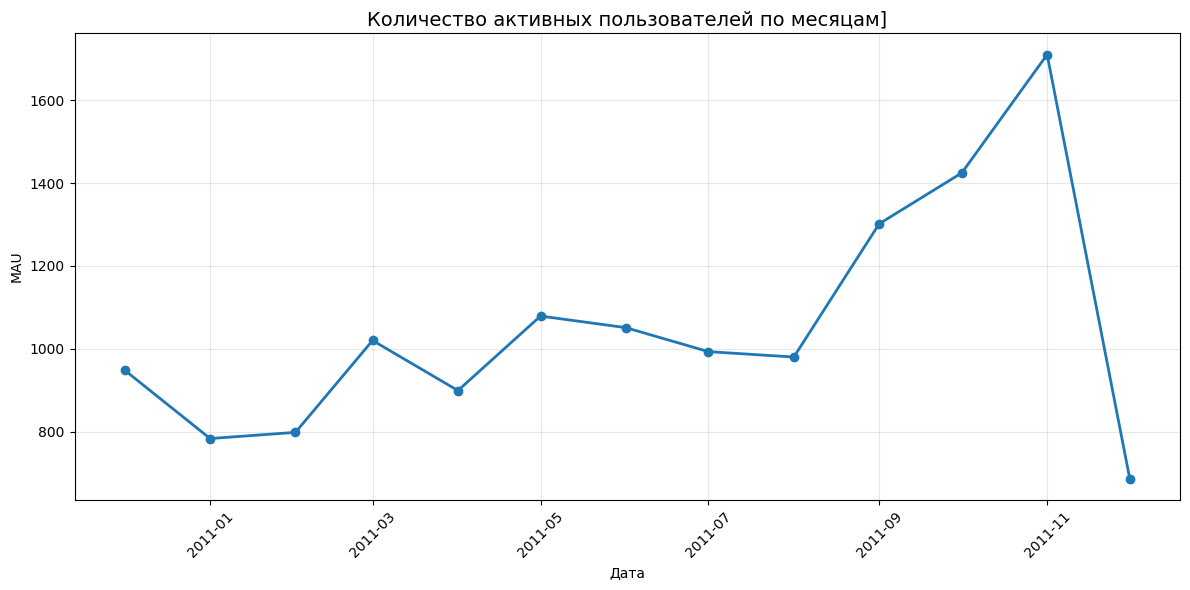

In [226]:
# Преобразуем месяц в дату
result['mnth_date'] = pd.to_datetime(result['mnth'] + '-01')

# График
plt.figure(figsize=(12, 6))
plt.plot(result['mnth_date'], result['mau'], marker='o', linestyle='-', linewidth=2)

plt.title('Количество активных пользователей по месяцам]', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('MAU')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Сводная таблица DAU, WAU, MAU**

In [227]:
query = """
WITH d AS (
SELECT
  data_only,
  count(distinct customer_id) as dau
FROM orders
GROUP BY 1
ORDER BY 1),

w as(
SELECT
  strftime('%Y-%W', data_only) as week,
  count(distinct customer_id) as wau
FROM orders
GROUP BY 1
ORDER BY 1
),

m AS(
SELECT
  strftime('%Y-%m', data_only) as mnth,
  count(distinct customer_id) as mau
FROM orders
GROUP BY 1
ORDER BY 1
)

SELECT
  d.data_only,
  d.dau,
  w.wau,
  m.mau
FROM d
LEFT JOIN w ON strftime('%Y-%W', d.data_only) = w.week
LEFT JOIN m ON strftime('%Y-%m', d.data_only) = m.mnth
"""
result = pd.read_sql_query(query, conn)
print(result)

               data_only  dau  wau  mau
0    2010-12-01 00:00:00   98  323  948
1    2010-12-02 00:00:00  117  323  948
2    2010-12-03 00:00:00   55  323  948
3    2010-12-05 00:00:00   76  323  948
4    2010-12-06 00:00:00   90  448  948
..                   ...  ...  ...  ...
300  2011-12-05 00:00:00  114  459  686
301  2011-12-06 00:00:00  128  459  686
302  2011-12-07 00:00:00  101  459  686
303  2011-12-08 00:00:00  120  459  686
304  2011-12-09 00:00:00   38  459  686

[305 rows x 4 columns]


## **Отмененные заказы: количество и доля**

In [228]:
query = """
with cancel as
(SELECT
  sum(unit_price * quantity) as canceled_amount,
  count(*) as decline_cnt
FROM orders
where invoice_no like 'c%'),

all_orders as(
SELECT
  sum(unit_price * quantity) as total_amount,
  count(*) as total_cnt
FROM orders
where invoice_no not like 'c%'
)

select
cancel.canceled_amount,
cancel.decline_cnt,
all_orders.total_amount,
all_orders.total_cnt,
round(cancel.decline_cnt * 100.0/ all_orders.total_cnt, 2) as canceled_cnt_rate_perc
from all_orders, cancel
"""
result = pd.read_sql_query(query, conn)
print(result)

   canceled_amount  decline_cnt  total_amount  total_cnt  \
0          -546055         8872       6369228     392732   

   canceled_cnt_rate_perc  
0                    2.26  


# Когортный анализ + Retention

## **Когорты по месяцам (первый заказ пользователя)**

In [229]:
query = """
WITH first_orders AS(
SELECT
  customer_id,
  MIN(data_only) as first_order_date,
  strftime('%Y-%m', MIN(data_only)) as cohort_month
FROM orders
GROUP BY 1
)

SELECT
  cohort_month,
  COUNT(DISTINCT customer_id) as size_cohort
FROM first_orders
GROUP BY 1
ORDER BY 1
"""
result = pd.read_sql_query(query, conn)
print(result)

   cohort_month  size_cohort
0       2010-12          948
1       2011-01          421
2       2011-02          380
3       2011-03          440
4       2011-04          299
5       2011-05          279
6       2011-06          235
7       2011-07          191
8       2011-08          167
9       2011-09          298
10      2011-10          352
11      2011-11          321
12      2011-12           41


## **Retention 1-й, 7-й, 14-й, 30-й день**

In [230]:
query = """
WITH first_orders AS(
SELECT
  customer_id,
  MIN(data_only) as first_order_date,
  strftime('%Y-%m', MIN(data_only)) as cohort_month
FROM orders
GROUP BY 1
),

user_activity AS (
SELECT
  f.customer_id,
  f.first_order_date,
  f.cohort_month,
  o.data_only as order_date,
  JULIANDAY(o.data_only) - JULIANDAY(f.first_order_date) as day_diff
FROM first_orders as f
LEFT JOIN orders as o ON f.customer_id = o.customer_id
WHERE o.data_only >= f.first_order_date
),

retention_days AS(
SELECT
  customer_id,
  cohort_month,
  MAX(CASE WHEN day_diff BETWEEN 1 and 1 THEN 1 ELSE 0 END) as day_1,
  MAX(CASE WHEN day_diff BETWEEN 1 and 7 THEN 1 ELSE 0 END) as day_7,
  MAX(CASE WHEN day_diff BETWEEN 1 and 14 THEN 1 ELSE 0 END) as day_14,
  MAX(CASE WHEN day_diff BETWEEN 1 and 30 THEN 1 ELSE 0 END) as day_30
FROM user_activity
GROUP BY 1, 2
)

SELECT
  cohort_month,
  COUNT(customer_id) as total_users,
  ROUND(100.0 * SUM(day_1) / COUNT(customer_id), 2) as retention_day_1,
  ROUND(100.0 * SUM(day_7) / COUNT(customer_id), 2) as retention_day_7,
  ROUND(100.0 * SUM(day_14) / COUNT(customer_id), 2) as retention_day_14,
  ROUND(100.0 * SUM(day_30) / COUNT(customer_id), 2) as retention_day_30
FROM retention_days
GROUP BY 1
ORDER BY 1
"""
result = pd.read_sql_query(query, conn)
print(result)

   cohort_month  total_users  retention_day_1  retention_day_7  \
0       2010-12          948             2.95            19.41   
1       2011-01          421             1.66            11.64   
2       2011-02          380             1.05            10.00   
3       2011-03          440             0.91             9.09   
4       2011-04          299             1.34            12.37   
5       2011-05          279             2.87            11.47   
6       2011-06          235             2.55            11.06   
7       2011-07          191             1.05             5.76   
8       2011-08          167             0.00             7.78   
9       2011-09          298             1.68            11.41   
10      2011-10          352             0.85             9.66   
11      2011-11          321             0.93            10.28   
12      2011-12           41             0.00             2.44   

    retention_day_14  retention_day_30  
0              29.75             3

## **Retention в виде heatmap**

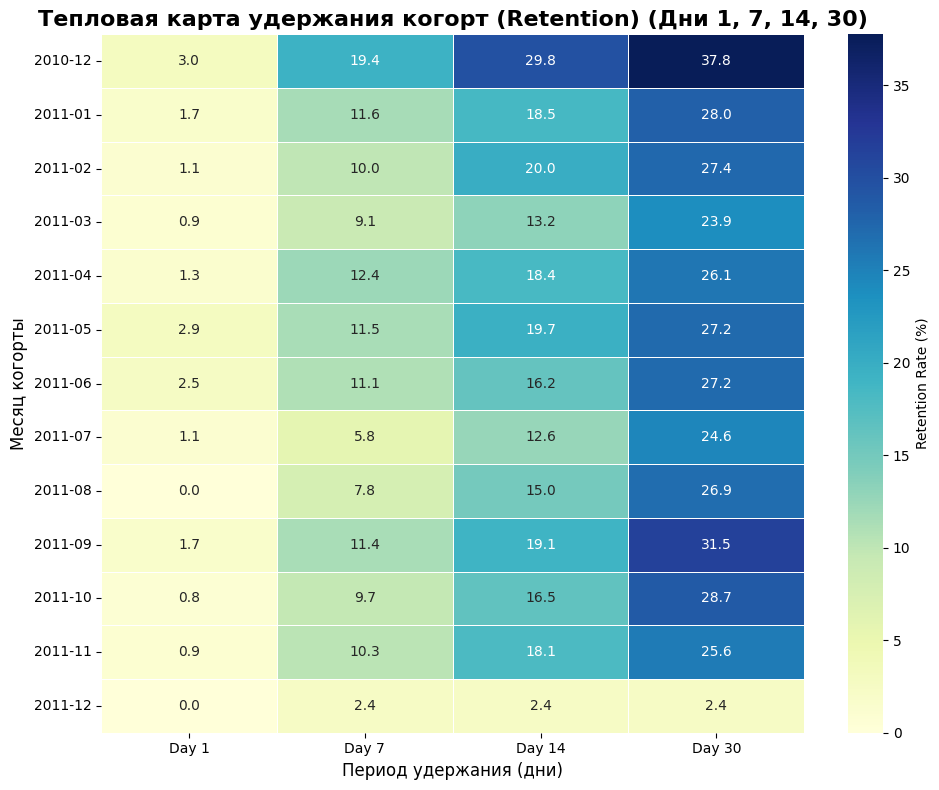

In [231]:
 # Берем только нужные колонки и делаем индексом cohort_month
retention_pivot = result.set_index('cohort_month')[['retention_day_1', 'retention_day_7', 'retention_day_14', 'retention_day_30']]
retention_pivot.columns = ['Day 1', 'Day 7', 'Day 14', 'Day 30']

# Сортируем по месяцам
retention_pivot = retention_pivot.sort_index()

# Строим heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('Тепловая карта удержания когорт (Retention) (Дни 1, 7, 14, 30)', fontsize=16, fontweight='bold')
plt.xlabel('Период удержания (дни)', fontsize=12)
plt.ylabel('Месяц когорты', fontsize=12)
plt.tight_layout()
plt.show()

# Денежные метрики

## **ARPU**

In [232]:
# Revenue / Кол-во уникальных пользователей
query = """
SELECT
  sum(unit_price * quantity) / count(distinct customer_id) as arpu
FROM orders
WHERE invoice_no NOT LIKE 'c%'
    AND quantity > 0;
"""
result = pd.read_sql_query(query, conn)
print(result)

   arpu
0  1467


## **ARPU по месяцам**

In [233]:
query = """
SELECT
  strftime('%Y-%m', data_only) as month,
  sum(unit_price * quantity) / count(distinct customer_id) as arpu
FROM orders
WHERE invoice_no NOT LIKE 'c%'
    AND quantity > 0
group by 1
order by 1
"""
result = pd.read_sql_query(query, conn)
print(result)

      month  arpu
0   2010-12   462
1   2011-01   571
2   2011-02   406
3   2011-03   422
4   2011-04   381
5   2011-05   456
6   2011-06   484
7   2011-07   439
8   2011-08   477
9   2011-09   540
10  2011-10   547
11  2011-11   496
12  2011-12   659


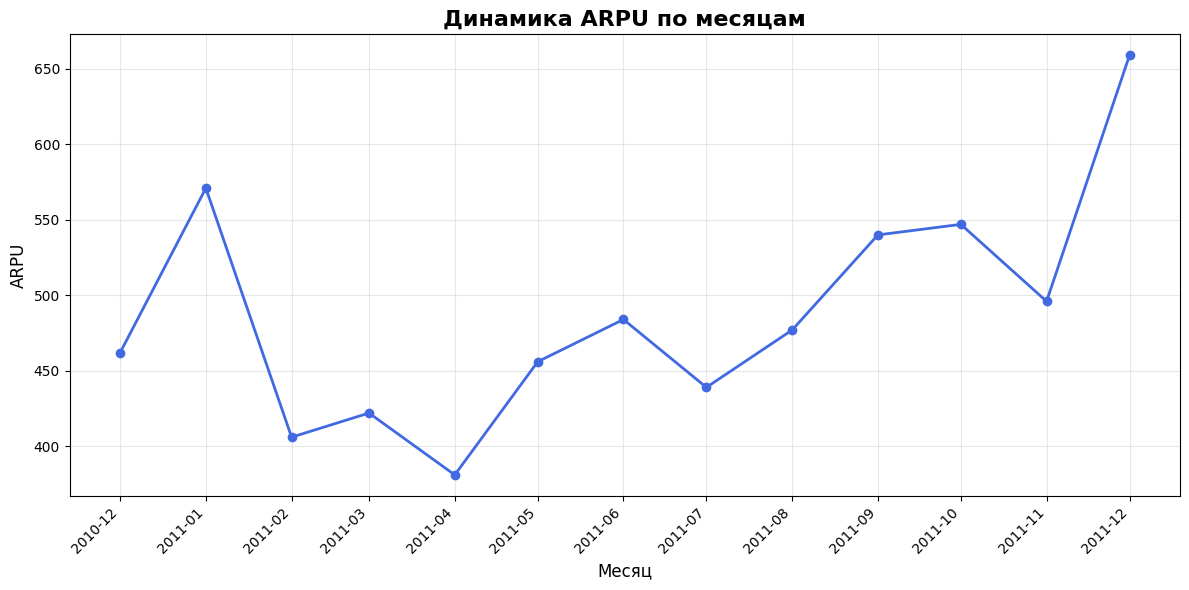

In [234]:
# Преобразуем месяц в дату для корректного отображения
result['month_date'] = pd.to_datetime(result['month'] + '-01')

# График
plt.figure(figsize=(12, 6))
plt.plot(result['month_date'], result['arpu'], marker='o', linestyle='-', linewidth=2, color='royalblue')

plt.title('Динамика ARPU по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('ARPU', fontsize=12)
plt.xticks(ticks=result['month_date'], labels=result['month'], rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **LTV**

In [235]:
query = """
-- фильтр корректных заказов
WITH valid_orders AS(
SELECT
  customer_id,
  data_only,
  invoice_no,
  quantity,
  unit_price,
  quantity * unit_price as revenue
FROM orders
WHERE invoice_no NOT LIKE 'c%'
  and quantity > 0
),

first_orders AS (
SELECT
  customer_id,
  MIN(data_only) as first_order_date,
  strftime('%Y-%m', MIN(data_only)) as cohort_month
FROM valid_orders
GROUP BY 1
),

cohort_ltv AS(
SELECT
  f.cohort_month,
  f.customer_id,
  sum(v.revenue) as total_revenue_per_user
FROM first_orders as f
LEFT JOIN valid_orders as v ON f.customer_id = v.customer_id
GROUP BY 1, 2
)

SELECT
  cohort_month,
  COUNT(customer_id) as total_users,
  ROUND(sum(total_revenue_per_user) / COUNT(customer_id) ,2) as LTV
FROM cohort_ltv
GROUP BY 1
ORDER BY 1
"""

result = pd.read_sql_query(query, conn)
print(result)

   cohort_month  total_users     LTV
0       2010-12          885  3632.0
1       2011-01          417  2001.0
2       2011-02          380  1075.0
3       2011-03          452   977.0
4       2011-04          300   751.0
5       2011-05          284  1265.0
6       2011-06          242   814.0
7       2011-07          188   525.0
8       2011-08          169   868.0
9       2011-09          299   540.0
10      2011-10          358   439.0
11      2011-11          324   318.0
12      2011-12           41   469.0


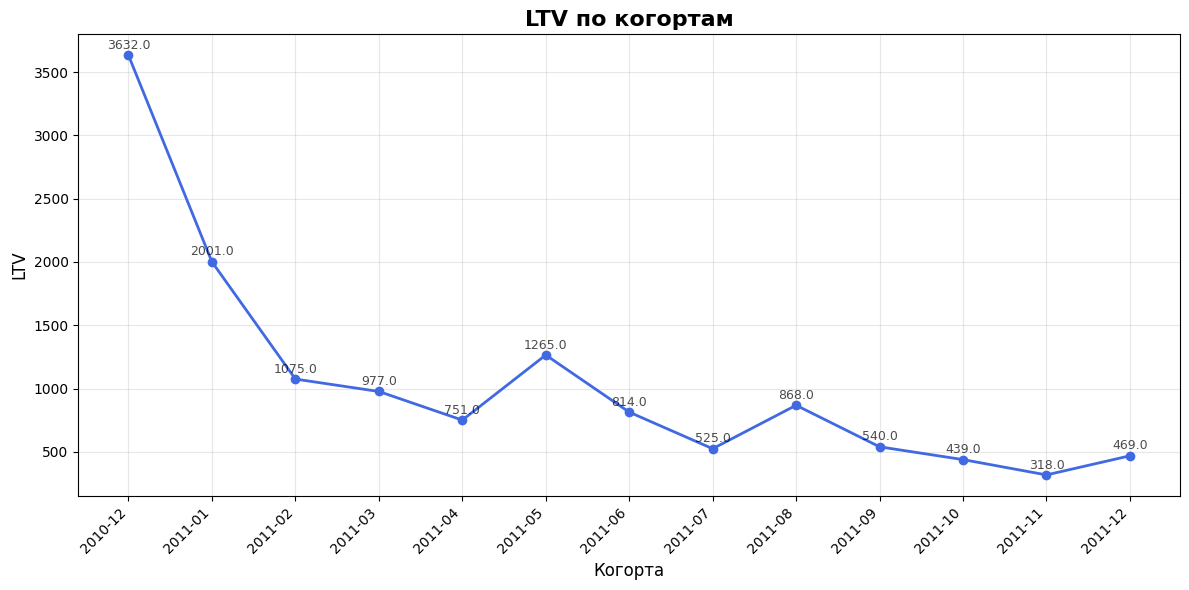

In [236]:
# Сортируем по месяцам
result = result.sort_values('cohort_month')

plt.figure(figsize=(12, 6))
plt.plot(result['cohort_month'], result['LTV'], marker='o', linestyle='-', linewidth=2, color='royalblue')

plt.title('LTV по когортам', fontsize=16, fontweight='bold')
plt.xlabel('Когорта', fontsize=12)
plt.ylabel('LTV', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Значения над точками
for x, y in zip(result['cohort_month'], result['LTV']):
    plt.text(x, y + 50, str(round(y, 0)), ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

In [237]:
# Кумулятивный LTV по месяцам
query = """
WITH valid_orders AS (
    SELECT
        customer_id,
        data_only,
        invoice_no,
        quantity,
        unit_price,
        quantity * unit_price AS revenue
    FROM orders
    WHERE
        invoice_no NOT LIKE 'c%'
        AND quantity > 0
),
first_orders AS (
    SELECT
        customer_id,
        MIN(data_only) AS first_order_date,
        strftime('%Y-%m', MIN(data_only)) AS cohort_month
    FROM valid_orders
    GROUP BY customer_id
),
cohort_monthly_revenue AS (
    SELECT
        f.cohort_month,
        f.customer_id,
        strftime('%Y-%m', v.data_only) AS activity_month,
        SUM(v.revenue) AS monthly_revenue
    FROM first_orders f
    LEFT JOIN valid_orders v ON f.customer_id = v.customer_id
    GROUP BY f.cohort_month, f.customer_id, activity_month
),
cohort_cumulative_ltv AS (
    SELECT
        cohort_month,
        customer_id,
        activity_month,
        SUM(monthly_revenue) OVER (PARTITION BY cohort_month, customer_id ORDER BY activity_month) AS cumulative_revenue
    FROM cohort_monthly_revenue
)
SELECT
    cohort_month,
    activity_month,
    ROUND(AVG(cumulative_revenue), 2) AS LTV
FROM cohort_cumulative_ltv
GROUP BY cohort_month, activity_month
ORDER BY cohort_month, activity_month;
"""

result = pd.read_sql_query(query, conn)
print(result)

   cohort_month activity_month      LTV
0       2010-12        2010-12   462.85
1       2010-12        2011-01  1263.78
2       2010-12        2011-02  1798.49
3       2010-12        2011-03  2191.47
4       2010-12        2011-04  2498.26
..          ...            ...      ...
86      2011-10        2011-11   655.97
87      2011-10        2011-12   826.66
88      2011-11        2011-11   290.77
89      2011-11        2011-12   560.42
90      2011-12        2011-12   469.83

[91 rows x 3 columns]


# ABC-анализ

In [238]:
query = """
WITH revenue_by_product AS (
SELECT
  stock_code,
  description,
  SUM(quantity * unit_price) as total_revenue
FROM orders
WHERE invoice_no NOT LIKE 'c%'
  AND quantity > 0
GROUP BY 1, 2
),

total_revenue_all AS (
SELECT SUM(total_revenue) as total_revenue
FROM revenue_by_product
),

ranked_products AS(
SELECT
  stock_code,
  description,
  total_revenue,
  ROUND(100.0 * total_revenue / (SELECT total_revenue FROM total_revenue_all), 2) as revenue_pct,
  ROUND(100.0 * SUM(total_revenue ) OVER (ORDER BY total_revenue DESC) / (SELECT total_revenue FROM total_revenue_all), 2) as cumulative_pct
FROM revenue_by_product
)

SELECT
    stock_code,
    description,
    total_revenue,
    revenue_pct,
    cumulative_pct,
    CASE
        WHEN cumulative_pct <= 80 THEN 'A'
        WHEN cumulative_pct <= 95 THEN 'B'
        ELSE 'C'
    END AS abc_group
FROM ranked_products
ORDER BY total_revenue DESC;
"""

result = pd.read_sql_query(query, conn)
print(result)

     stock_code                         description  total_revenue  \
0         23843         PAPER CRAFT , LITTLE BIRDIE         161990   
1         22423            REGENCY CAKESTAND 3 TIER         131322   
2         23166      MEDIUM CERAMIC TOP STORAGE JAR          77916   
3          POST                             POSTAGE          77797   
4        85123A  WHITE HANGING HEART T-LIGHT HOLDER          77568   
...         ...                                 ...            ...   
3892     90214T           LETTER "T" BLING KEY RING              0   
3893     90214U           LETTER "U" BLING KEY RING              0   
3894     90214W           LETTER "W" BLING KEY RING              0   
3895     90214Z           LETTER "Z" BLING KEY RING              0   
3896       PADS          PADS TO MATCH ALL CUSHIONS              0   

      revenue_pct  cumulative_pct abc_group  
0            2.54            2.54         A  
1            2.06            4.61         A  
2            1.22    

## **Сводка по группам (сколько товаров, сколько выручки)**

In [239]:
query = """
WITH revenue_by_product AS (
    SELECT
        stock_code,
        SUM(quantity * unit_price) AS total_revenue
    FROM orders
    WHERE
        invoice_no NOT LIKE 'c%'
        AND quantity > 0
    GROUP BY stock_code
),
total_revenue_all AS (
    SELECT SUM(total_revenue) AS total_revenue
    FROM revenue_by_product
),
ranked_products AS (
    SELECT
        stock_code,
        total_revenue,
        ROUND(100.0 * SUM(total_revenue) OVER (ORDER BY total_revenue DESC) / (SELECT total_revenue FROM total_revenue_all), 2) AS cumulative_pct
    FROM revenue_by_product
)
SELECT
    CASE
        WHEN cumulative_pct <= 80 THEN 'A'
        WHEN cumulative_pct <= 95 THEN 'B'
        ELSE 'C'
    END AS abc_group,
    COUNT(*) AS product_count,
    ROUND(SUM(total_revenue), 0) AS total_revenue,
    ROUND(100.0 * SUM(total_revenue) / (SELECT total_revenue FROM total_revenue_all), 2) AS revenue_pct
FROM ranked_products
GROUP BY abc_group
ORDER BY abc_group;
"""
result = pd.read_sql_query(query, conn)
print(result)

  abc_group  product_count  total_revenue  revenue_pct
0         A            573      5095226.0         80.0
1         B            644       955263.0         15.0
2         C           2448       318739.0          5.0


## **Топ-10 товаров группы A (самые ценные)**

In [240]:
query = """
WITH revenue_by_product AS (
    SELECT
        stock_code,
        description,
        SUM(quantity * unit_price) AS total_revenue
    FROM orders
    WHERE
        invoice_no NOT LIKE 'c%'
        AND quantity > 0
    GROUP BY stock_code, description
),
total_revenue_all AS (
    SELECT SUM(total_revenue) AS total_revenue
    FROM revenue_by_product
),
ranked_products AS (
    SELECT
        stock_code,
        description,
        total_revenue,
        ROUND(100.0 * SUM(total_revenue) OVER (ORDER BY total_revenue DESC) / (SELECT total_revenue FROM total_revenue_all), 2) AS cumulative_pct
    FROM revenue_by_product
)
SELECT
    stock_code,
    description,
    total_revenue,
    cumulative_pct
FROM ranked_products
WHERE cumulative_pct <= 80
ORDER BY total_revenue DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
print(result)

  stock_code                         description  total_revenue  \
0      23843         PAPER CRAFT , LITTLE BIRDIE         161990   
1      22423            REGENCY CAKESTAND 3 TIER         131322   
2      23166      MEDIUM CERAMIC TOP STORAGE JAR          77916   
3       POST                             POSTAGE          77797   
4     85123A  WHITE HANGING HEART T-LIGHT HOLDER          77568   
5      47566                       PARTY BUNTING          60278   
6     85099B             JUMBO BAG RED RETROSPOT          57520   
7          M                              Manual          51450   
8      22502      PICNIC BASKET WICKER 60 PIECES          39589   
9      79321                       CHILLI LIGHTS          38903   

   cumulative_pct  
0            2.54  
1            4.61  
2            5.83  
3            7.05  
4            8.27  
5            9.21  
6           10.12  
7           10.93  
8           11.55  
9           12.16  


# Экономика (с генерацией CAC = 5$ на пользователя)

## **ROI** и ****CAC Payback Period****

In [241]:
# (LTV - CAC) / CAC и CAC / (Revenue per user per month)

In [242]:
query = """
WITH cohort_ltv AS (
    -- Твой запрос LTV по когортам
    SELECT
        strftime('%Y-%m', MIN(data_only)) AS cohort_month,
        customer_id,
        SUM(quantity * unit_price) AS total_revenue
    FROM orders
    WHERE
        invoice_no NOT LIKE 'c%'
        AND quantity > 0
        AND customer_id IS NOT NULL
    GROUP BY customer_id
),
cohort_metrics AS (
    SELECT
        cohort_month,
        COUNT(customer_id) AS total_users,
        ROUND(SUM(total_revenue) / COUNT(customer_id), 2) AS LTV,
        ROUND(SUM(total_revenue) / COUNT(customer_id) / 12, 2) AS revenue_per_user_per_month  -- 12 месяцев наблюдения
    FROM cohort_ltv
    GROUP BY cohort_month
)
SELECT
    cohort_month,
    total_users,
    LTV,
    revenue_per_user_per_month,
    ROUND((LTV - 5) / 5, 2) AS ROI,                           -- CAC = 5
    ROUND(5 / NULLIF(revenue_per_user_per_month, 0), 2) AS cac_payback_period_months
FROM cohort_metrics
ORDER BY cohort_month
"""

result = pd.read_sql_query(query, conn)
print(result)

   cohort_month  total_users     LTV  revenue_per_user_per_month    ROI  \
0       2010-12          885  3632.0                       302.0  725.4   
1       2011-01          417  2001.0                       166.0  399.2   
2       2011-02          380  1075.0                        89.0  214.0   
3       2011-03          452   977.0                        81.0  194.4   
4       2011-04          300   751.0                        62.0  149.2   
5       2011-05          284  1265.0                       105.0  252.0   
6       2011-06          242   814.0                        67.0  161.8   
7       2011-07          188   525.0                        43.0  104.0   
8       2011-08          169   868.0                        72.0  172.6   
9       2011-09          299   540.0                        45.0  107.0   
10      2011-10          358   439.0                        36.0   86.8   
11      2011-11          324   318.0                        26.0   62.6   
12      2011-12          

# Дополнительные метрики

## **Churn Rate**

In [243]:
# пользователь будет считаться ушедшим, если не совершал покупок в течении последних N-дней
query = """
WITH user_last_activity AS (
    SELECT
        customer_id,
        MAX(data_only) AS last_order_date
    FROM orders
    WHERE
        invoice_no NOT LIKE 'c%'
        AND quantity > 0
        AND customer_id IS NOT NULL
    GROUP BY customer_id
),
total_users AS (
    SELECT COUNT(DISTINCT customer_id) AS total_users
    FROM user_last_activity
)
SELECT
    total_users,
    COUNT(CASE WHEN last_order_date < DATE('2011-12-09', '-30 days') THEN 1 END) AS churned_30d,
    ROUND(100.0 * COUNT(CASE WHEN last_order_date < DATE('2011-12-09', '-30 days') THEN 1 END) / total_users, 2) AS churn_rate_30d,
    COUNT(CASE WHEN last_order_date < DATE('2011-12-09', '-60 days') THEN 1 END) AS churned_60d,
    ROUND(100.0 * COUNT(CASE WHEN last_order_date < DATE('2011-12-09', '-60 days') THEN 1 END) / total_users, 2) AS churn_rate_60d,
    COUNT(CASE WHEN last_order_date < DATE('2011-12-09', '-90 days') THEN 1 END) AS churned_90d,
    ROUND(100.0 * COUNT(CASE WHEN last_order_date < DATE('2011-12-09', '-90 days') THEN 1 END) / total_users, 2) AS churn_rate_90d
FROM user_last_activity, total_users;
"""

result = pd.read_sql_query(query, conn)
print(result)

   total_users  churned_30d  churn_rate_30d  churned_60d  churn_rate_60d  \
0         4339         2671           61.56         1928           44.43   

   churned_90d  churn_rate_90d  
0         1449           33.39  


## **Churn Rate по месяцам**

In [244]:
query = """
WITH user_last_activity AS (
    SELECT
        customer_id,
        MAX(data_only) AS last_order_date,
        strftime('%Y-%m', MAX(data_only)) AS last_active_month
    FROM orders
    WHERE
        invoice_no NOT LIKE 'c%'
        AND quantity > 0
        AND customer_id IS NOT NULL
    GROUP BY customer_id
),
cohort_churn AS (
    SELECT
        strftime('%Y-%m', first_order) AS cohort_month,
        COUNT(DISTINCT customer_id) AS total_users,
        COUNT(DISTINCT CASE
            WHEN last_order_date < DATE('2011-12-09', '-30 days')
            THEN customer_id
        END) AS churned_users_30d,
        COUNT(DISTINCT CASE
            WHEN last_order_date < DATE('2011-12-09', '-60 days')
            THEN customer_id
        END) AS churned_users_60d,
        COUNT(DISTINCT CASE
            WHEN last_order_date < DATE('2011-12-09', '-90 days')
            THEN customer_id
        END) AS churned_users_90d
    FROM (
        SELECT
            customer_id,
            MIN(data_only) AS first_order
        FROM orders
        WHERE
            invoice_no NOT LIKE 'c%'
            AND quantity > 0
            AND customer_id IS NOT NULL
        GROUP BY customer_id
    ) first_orders
    LEFT JOIN user_last_activity USING (customer_id)
    GROUP BY cohort_month
)
SELECT
    cohort_month,
    total_users,
    churned_users_30d,
    ROUND(100.0 * churned_users_30d / total_users, 2) AS churn_rate_30d,
    churned_users_60d,
    ROUND(100.0 * churned_users_60d / total_users, 2) AS churn_rate_60d,
    churned_users_90d,
    ROUND(100.0 * churned_users_90d / total_users, 2) AS churn_rate_90d
FROM cohort_churn
ORDER BY cohort_month;
"""

result = pd.read_sql_query(query, conn)
print(result)

   cohort_month  total_users  churned_users_30d  churn_rate_30d  \
0       2010-12          885                414           46.78   
1       2011-01          417                271           64.99   
2       2011-02          380                275           72.37   
3       2011-03          452                333           73.67   
4       2011-04          300                223           74.33   
5       2011-05          284                200           70.42   
6       2011-06          242                158           65.29   
7       2011-07          188                134           71.28   
8       2011-08          169                123           72.78   
9       2011-09          299                208           69.57   
10      2011-10          358                268           74.86   
11      2011-11          324                 64           19.75   
12      2011-12           41                  0            0.00   

    churned_users_60d  churn_rate_60d  churned_users_90d  chu

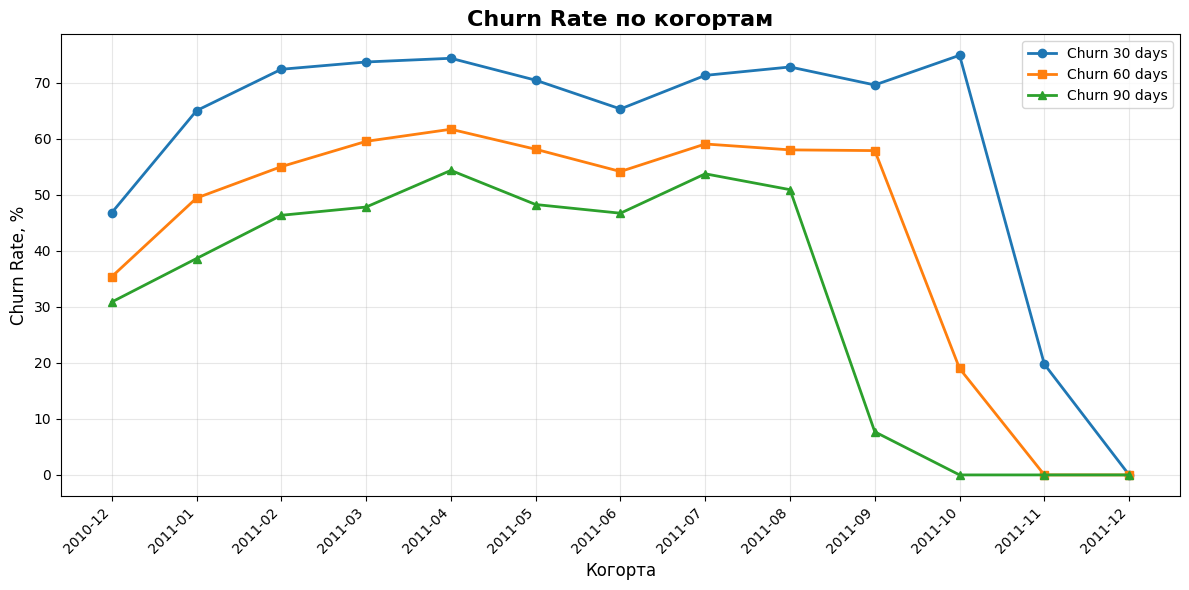

In [245]:
# Сортируем
churn_df = result.sort_values('cohort_month')

plt.figure(figsize=(12, 6))
plt.plot(churn_df['cohort_month'], churn_df['churn_rate_30d'], marker='o', label='Churn 30 days', linewidth=2)
plt.plot(churn_df['cohort_month'], churn_df['churn_rate_60d'], marker='s', label='Churn 60 days', linewidth=2)
plt.plot(churn_df['cohort_month'], churn_df['churn_rate_90d'], marker='^', label='Churn 90 days', linewidth=2)

plt.title('Churn Rate по когортам', fontsize=16, fontweight='bold')
plt.xlabel('Когорта', fontsize=12)
plt.ylabel('Churn Rate, %', fontsize=12)
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Average Order Value**

In [246]:
query = """
SELECT
    ROUND(SUM(quantity * unit_price) / COUNT(DISTINCT invoice_no), 2) AS AOV
FROM orders
WHERE
    invoice_no NOT LIKE 'c%'
    AND quantity > 0
    AND customer_id IS NOT NULL;
"""

result = pd.read_sql_query(query, conn)
print(result)

     AOV
0  343.0


## **Average Order Value по месяцам**

In [247]:
query = """
SELECT
    strftime('%Y-%m', data_only) AS month,
    ROUND(SUM(quantity * unit_price) / COUNT(DISTINCT invoice_no), 2) AS AOV
FROM orders
WHERE
    invoice_no NOT LIKE 'c%'
    AND quantity > 0
    AND customer_id IS NOT NULL
GROUP BY month
ORDER BY month;
"""

result = pd.read_sql_query(query, conn)
print(result)

      month    AOV
0   2010-12  292.0
1   2011-01  429.0
2   2011-02  308.0
3   2011-03  311.0
4   2011-04  284.0
5   2011-05  310.0
6   2011-06  344.0
7   2011-07  313.0
8   2011-08  348.0
9   2011-09  389.0
10  2011-10  387.0
11  2011-11  311.0
12  2011-12  521.0


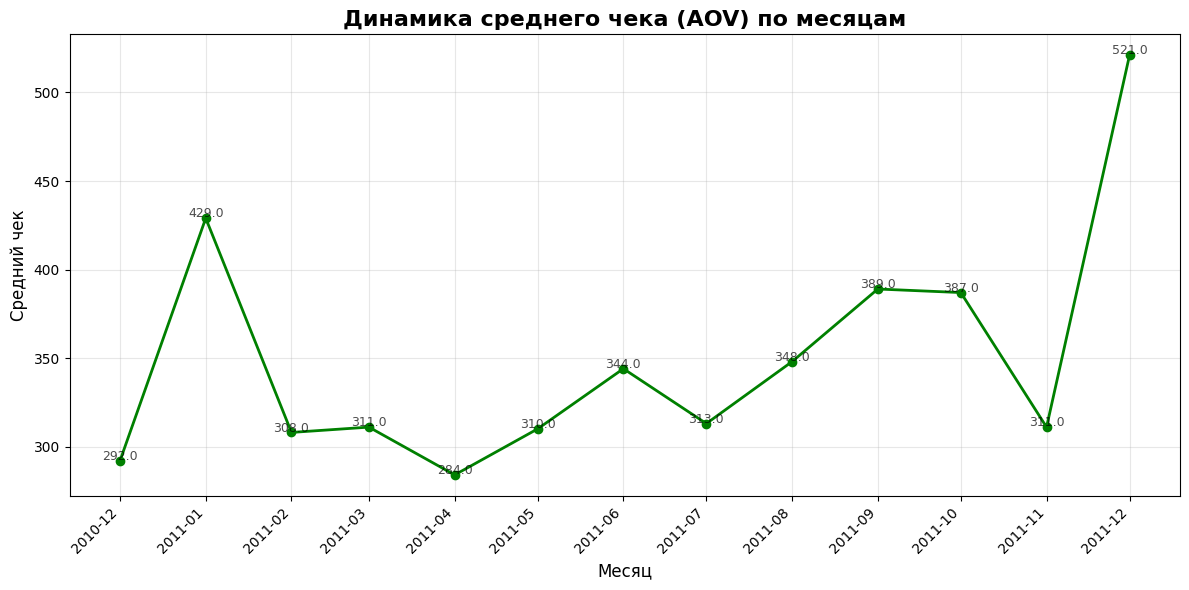

In [248]:
# Преобразуем месяц в дату для корректного отображения на оси X
result['month_date'] = pd.to_datetime(result['month'] + '-01')

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(result['month_date'], result['AOV'], marker='o', linestyle='-', linewidth=2, color='green')

# Заголовки и подписи
plt.title('Динамика среднего чека (AOV) по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Средний чек', fontsize=12)
plt.xticks(ticks=result['month_date'], labels=result['month'], rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Добавляем значения над точками
for x, y in zip(result['month_date'], result['AOV']):
    plt.text(x, y + 0.5, str(round(y, 2)), ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

## **Purchase Frequency**

In [249]:
query = """
SELECT
    ROUND(
        COUNT(DISTINCT invoice_no) * 1.0 / COUNT(DISTINCT customer_id),
        2
    ) AS purchase_frequency
FROM orders
WHERE
    invoice_no NOT LIKE 'c%'
    AND quantity > 0
    AND customer_id IS NOT NULL;
"""

result = pd.read_sql_query(query, conn)
print(result)

   purchase_frequency
0                4.27


## **Purchase Frequency по месяцам**

In [250]:
query = """
SELECT
    strftime('%Y-%m', data_only) AS month,
    ROUND(
        COUNT(DISTINCT invoice_no) * 1.0 / COUNT(DISTINCT customer_id),
        2
    ) AS purchase_frequency
FROM orders
WHERE
    invoice_no NOT LIKE 'c%'
    AND quantity > 0
    AND customer_id IS NOT NULL
GROUP BY month
ORDER BY month;
"""

result = pd.read_sql_query(query, conn)
print(result)

      month  purchase_frequency
0   2010-12                1.58
1   2011-01                1.33
2   2011-02                1.32
3   2011-03                1.36
4   2011-04                1.34
5   2011-05                1.47
6   2011-06                1.41
7   2011-07                1.40
8   2011-08                1.37
9   2011-09                1.39
10  2011-10                1.41
11  2011-11                1.60
12  2011-12                1.27


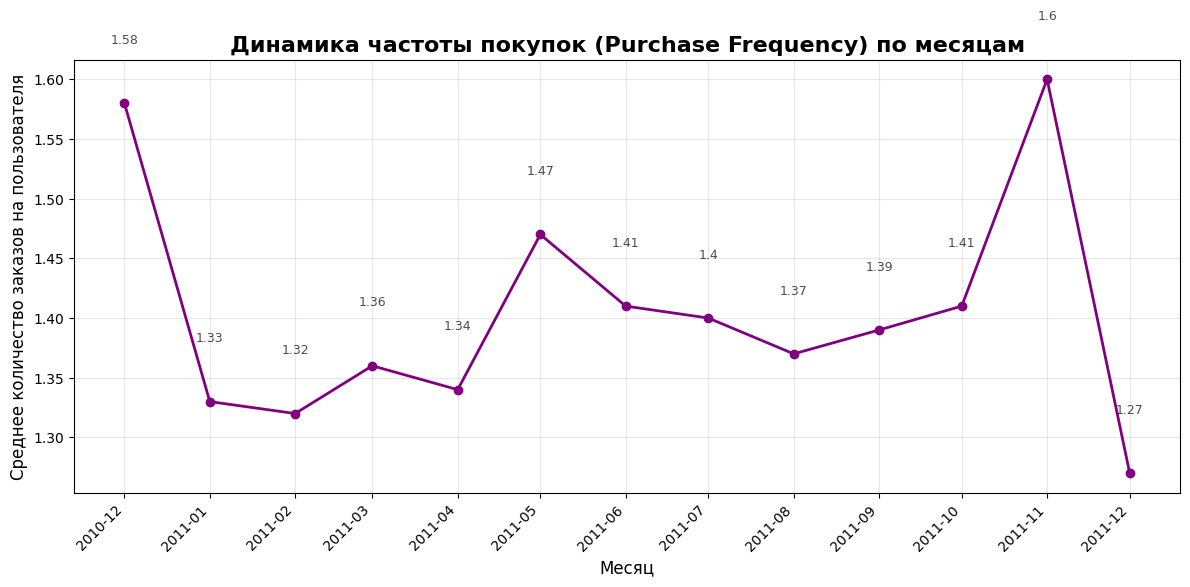

In [251]:
# Преобразуем месяц в дату
result['month_date'] = pd.to_datetime(result['month'] + '-01')

# График
plt.figure(figsize=(12, 6))
plt.plot(result['month_date'], result['purchase_frequency'], marker='o', linestyle='-', linewidth=2, color='purple')

plt.title('Динамика частоты покупок (Purchase Frequency) по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Среднее количество заказов на пользователя', fontsize=12)
plt.xticks(ticks=result['month_date'], labels=result['month'], rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Значения над точками
for x, y in zip(result['month_date'], result['purchase_frequency']):
    plt.text(x, y + 0.05, str(round(y, 2)), ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

# Закрытие соединения

In [252]:
conn.close()

# Выводы


## Данные и предобработка
- Загружены транзакционные данные интернет-магазина за период 01.12.2010 — 09.12.2011 (401 604 строк после чистки)

- Удалены дубликаты и строки без customer_id (гостевые покупки исключены из анализа)

- Создан отдельный столбец data_only для группировок по датам

## Метрики аудитории
- DAU колеблется от 38 до 128 пользователей в день

- WAU вырос с 323 (дек. 2010) до 582 (нояб. 2011) — рост на 80%

- MAU вырос с 948 (дек. 2010) до 1 711 (нояб. 2011), что указывает на устойчивый рост аудитории в течение года

- Отмененные заказы составляют ~2.26% от всех заказов

## Когортный анализ + Retention
- Самая большая когорта — декабрь 2010 (948 пользователей), что связано с предновогодним сезоном

- Retention на 30-й день в среднем составляет 25–30% по всем когортам

- Когорта декабря 2010 показывает лучшее удержание (37.76% на Day 30), что говорит о высокой лояльности первых пользователей

- Летние когорты (июль–август) демонстрируют снижение удержания — возможна сезонность

## Денежные метрики
- ARPU вырос с 462 (дек. 2010) до 659 (дек. 2011), что подтверждает рост монетизации

- LTV старых когорт значительно выше молодых (самая старая когорта — LTV = 3 632), что объясняется большим временем наблюдения

- Кумулятивный LTV показывает, что основная выручка накапливается в первые 3–6 месяцев жизни пользователя

## ABC-анализ
- Группа A (80% выручки) — всего 573 товара (основа ассортимента)

- Группа B (15% выручки) — 644 товара

- Группа C (5% выручки) — 2 448 товаров (кандидаты на исключение)

**Рекомендация:** Сосредоточить маркетинг на товарах группы A, пересмотреть ассортимент группы C

## Экономика (ROI, CAC Payback Period)
- При гипотетическом CAC = $5:

  - ROI для когорты декабря 2010 составил 725%

  - CAC Payback Period — менее 1 месяца для всех когорт

## Дополнительные метрики
- Churn Rate за 30 дней: ~61.6% в целом, что выше среднего

- AOV (средний чек): 343 в среднем, с пиком в декабре (521)

- Purchase Frequency: в среднем 4.27 заказов на пользователя за весь период